<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Weather Forecasting Using Machine Learning Techniques: Predictive Modeling and Analysis for Accurate Meteorological Predictions**



**Dataset:** [Seattle Weather Dataset](https://www.kaggle.com/datasets/ananthr1/weather-prediction)
— 1,461 daily observations (2012–2015) with features: `precipitation`, `temp_max`, `temp_min`,
`wind` speed, and a 5-class weather label.



# Setting up Kaggle API for getting the dataset



Then upload the `kaggle.json` file in Google Colab and then run the below commands


In [ ]:
! pip install kaggle -q
! mkdir ~/.kaggle                        
! cp kaggle.json ~/.kaggle/              
! chmod 600 ~/.kaggle/kaggle.json        


In [ ]:
! kaggle datasets download -d ananthr1/weather-prediction    


Dataset URL: https://www.kaggle.com/datasets/ananthr1/weather-prediction
License(s): CC-BY-NC-SA-4.0
  0% 0.00/11.5k [00:00<?, ?B/s]
100% 11.5k/11.5k [00:00<00:00, 41.1MB/s]


In [ ]:
! unzip -q weather-prediction.zip    
! ls *.csv


seattle-weather.csv


# Importing Necessary Libraries
<hr>


In [ ]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np                          
import pandas as pd                         
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Sklearn – preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

# Sklearn – metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score)

# Sklearn – models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Feature selection
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.decomposition import PCA

# Imbalance
from imblearn.over_sampling import SMOTE

# Scipy
from scipy import stats

import joblib
print("All libraries imported ✓")


All libraries imported ✓


In [ ]:
df = pd.read_csv('seattle-weather.csv')    

df.head(5), df.shape                       


(         date  precipitation  temp_max  temp_min  wind  weather
 0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
 1  2012-01-02           10.9      10.6       2.8   4.5     rain
 2  2012-01-03            0.8      11.7       7.2   2.3     rain
 3  2012-01-04           20.3      12.2       5.6   4.7     rain
 4  2012-01-05            1.3       8.9       2.8   6.1     rain,
 (1461, 6))

# Exploratory Data Analysis
<hr>


In [6]:
print("Null values present in the file:", df.isna().sum().sum())
print("\nBasic information about the dataframe:")
df.info()

df.describe()


Null values present in the file: 0

Basic information about the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [ ]:

weather_types = df['weather'].unique().tolist()
WEATHER_MAP   = {i: w for i, w in enumerate(sorted(weather_types))}
print("Weather types in dataset:")
for k, v in WEATHER_MAP.items():
    print(f"  {k} → {v}")


Weather types in dataset:
  0 → drizzle
  1 → fog
  2 → rain
  3 → snow
  4 → sun


## Number of observations present in the dataset corresponding to each weather type

In [8]:
count_weather = df['weather'].value_counts().to_frame()
count_weather.columns = ['count']
count_weather['weather type'] = count_weather.index
count_weather


,count,weather type
weather,,
rain,641,rain
sun,640,sun
fog,101,fog
drizzle,53,drizzle
snow,26,snow


## Number of observations per year in the dataset

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
count_year = df.groupby('year')['weather'].count().to_frame()
count_year.columns = ['observations']
count_year


,observations
year,
2012,366
2013,365
2014,365
2015,365


### Weather Type Class Distribution (Bar Chart)


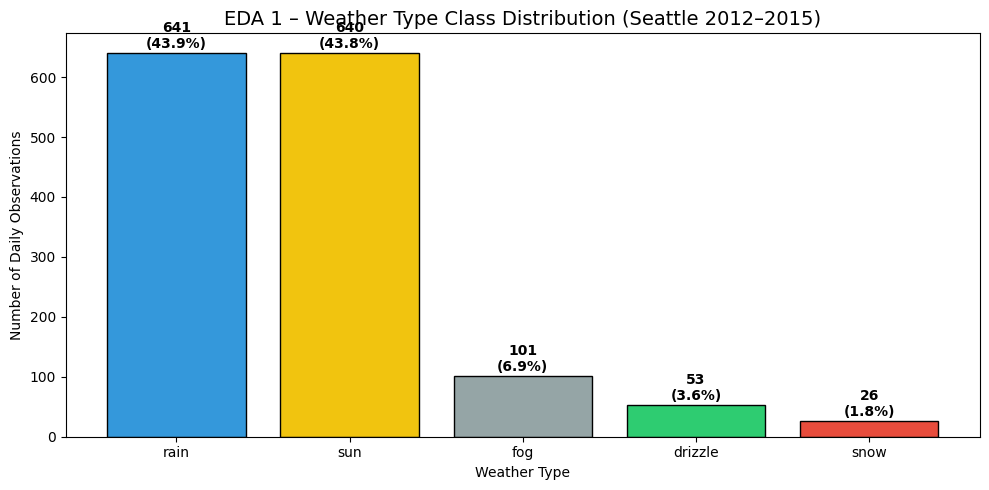

Class counts:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26


In [ ]:

counts = df['weather'].value_counts().sort_values(ascending=False)
colors = ['#3498db','#f1c40f','#95a5a6','#2ecc71','#e74c3c']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{cnt}\n({cnt/len(df)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('EDA 1 – Weather Type Class Distribution (Seattle 2012–2015)', fontsize=14)
ax.set_xlabel('Weather Type'); ax.set_ylabel('Number of Daily Observations')
plt.tight_layout(); plt.show()
print("Class counts:")
print(counts.to_string())


### Observations per Year (Pie Chart)



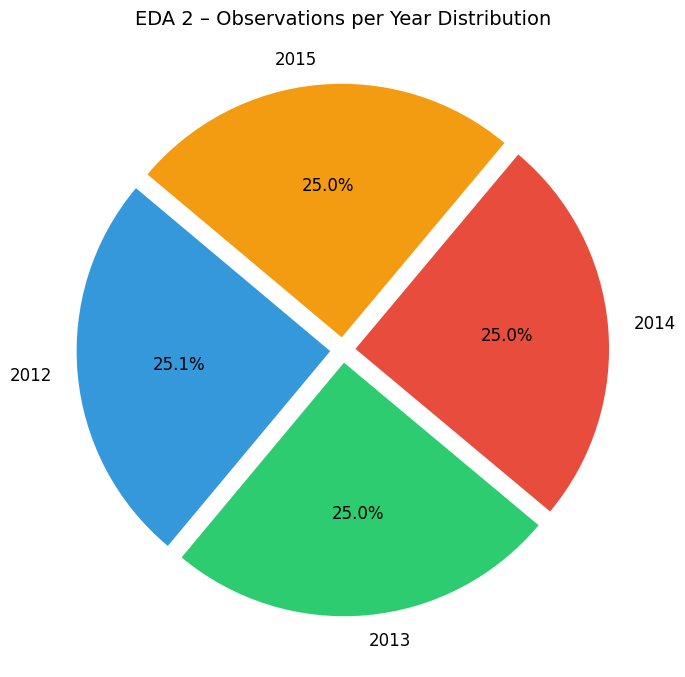

year
2012    366
2013    365
2014    365
2015    365
Name: count, dtype: int64


In [ ]:

year_counts = df['year'].value_counts().sort_index()
colors_pie  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
explode     = [0.05] * len(year_counts)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    year_counts.values, labels=[str(y) for y in year_counts.index],
    autopct='%1.1f%%', colors=colors_pie, explode=explode,
    startangle=140, textprops={'fontsize': 12}
)
ax.set_title('EDA 2 – Observations per Year Distribution', fontsize=14)
plt.tight_layout(); plt.show()
print(year_counts)


##  Monthly Weather Frequency per Type (Grouped Bar)



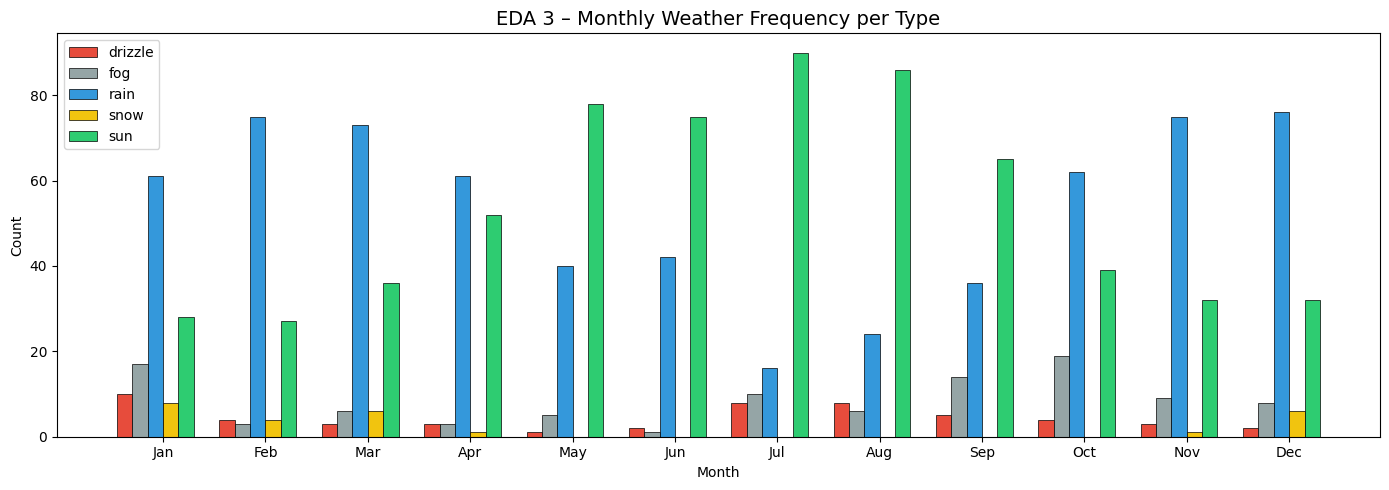

In [ ]:

df['month'] = df['date'].dt.month
weather_sorted = sorted(df['weather'].unique())
monthly_counts = df.groupby(['month','weather']).size().unstack(fill_value=0)
monthly_counts = monthly_counts.reindex(columns=weather_sorted, fill_value=0)

colors_w = ['#e74c3c','#95a5a6','#3498db','#f1c40f','#2ecc71']
x = np.arange(1, 13)
width = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
for idx, (wtype, color) in enumerate(zip(weather_sorted, colors_w)):
    ax.bar(x + idx*width,
           [monthly_counts.loc[m, wtype] if m in monthly_counts.index else 0 for m in range(1,13)],
           width, label=wtype, color=color, edgecolor='black', linewidth=0.5)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks(x + width * len(weather_sorted)/2)
ax.set_xticklabels(month_names)
ax.set_title('EDA 3 – Monthly Weather Frequency per Type', fontsize=14)
ax.set_xlabel('Month'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()


### Meteorological Feature Statistics per Weather Type


EDA 4 – Meteorological Feature Statistics per Weather Type
Weather       Feature   Mean   Std  Min  Max  Count
drizzle precipitation  0.000 0.000  0.0  0.0     53
drizzle      temp_max 15.926 8.812  1.1 31.7     53
drizzle      temp_min  7.111 6.182 -3.9 16.1     53
drizzle          wind  2.368 0.911  0.6  4.7     53
    fog precipitation  0.000 0.000  0.0  0.0    101
    fog      temp_max 16.757 6.775  1.7 30.6    101
    fog      temp_min  7.979 5.012 -3.2 17.8    101
    fog          wind  2.481 1.197  0.8  6.6    101
   rain precipitation  6.558 8.648  0.0 55.9    641
   rain      temp_max 13.455 4.973  3.9 35.6    641
   rain      temp_min  7.589 3.952 -3.8 18.3    641
   rain          wind  3.670 1.586  0.5  9.5    641
   snow precipitation  8.554 7.022  0.3 23.9     26
   snow      temp_max  5.573 3.109 -1.1 11.1     26
   snow      temp_min  0.146 2.237 -4.3  5.6     26
   snow          wind  4.412 1.440  1.6  7.0     26
    sun precipitation  0.000 0.000  0.0  0.0    640
    s

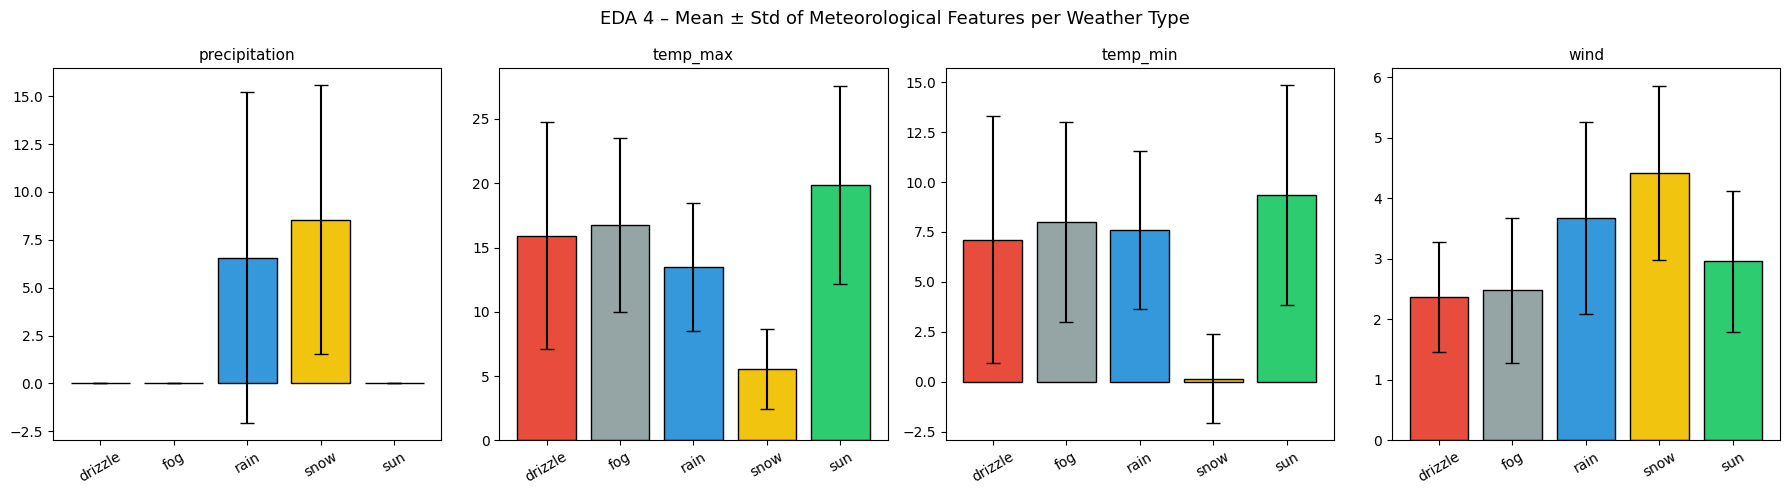

In [ ]:

numeric_feats = ['precipitation', 'temp_max', 'temp_min', 'wind']
rows = []
for wtype in sorted(df['weather'].unique()):
    sub = df[df['weather'] == wtype][numeric_feats]
    for feat in numeric_feats:
        rows.append({
            'Weather':  wtype,
            'Feature':  feat,
            'Mean':     round(sub[feat].mean(), 3),
            'Std':      round(sub[feat].std(),  3),
            'Min':      round(sub[feat].min(),  3),
            'Max':      round(sub[feat].max(),  3),
            'Count':    len(sub)
        })

stats_df = pd.DataFrame(rows)
print("EDA 4 – Meteorological Feature Statistics per Weather Type")
print(stats_df.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
weather_order = sorted(df['weather'].unique())
colors_bar    = ['#e74c3c','#95a5a6','#3498db','#f1c40f','#2ecc71']
for ax, feat in zip(axes, numeric_feats):
    means = [df[df['weather']==w][feat].mean() for w in weather_order]
    stds  = [df[df['weather']==w][feat].std()  for w in weather_order]
    ax.bar(weather_order, means, yerr=stds, color=colors_bar, edgecolor='black', capsize=5)
    ax.set_title(feat, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('EDA 4 – Mean ± Std of Meteorological Features per Weather Type', fontsize=13)
plt.tight_layout(); plt.show()


## Sample Count Heatmap (Weather Type × Year)



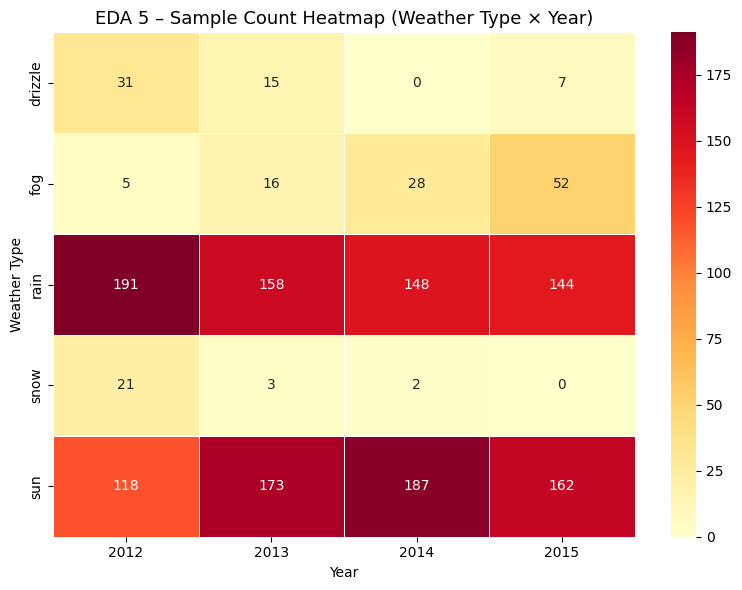

In [ ]:

years   = sorted(df['year'].unique())
weather_order = sorted(df['weather'].unique())

matrix = np.array([
    [df[(df['year']==y) & (df['weather']==w)].shape[0] for y in years]
    for w in weather_order
])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[str(y) for y in years],
            yticklabels=weather_order,
            linewidths=0.5, ax=ax)
ax.set_title('EDA 5 – Sample Count Heatmap (Weather Type × Year)', fontsize=13)
ax.set_xlabel('Year'); ax.set_ylabel('Weather Type')
plt.tight_layout(); plt.show()


## Visualising the Meteorological Time-Series Data

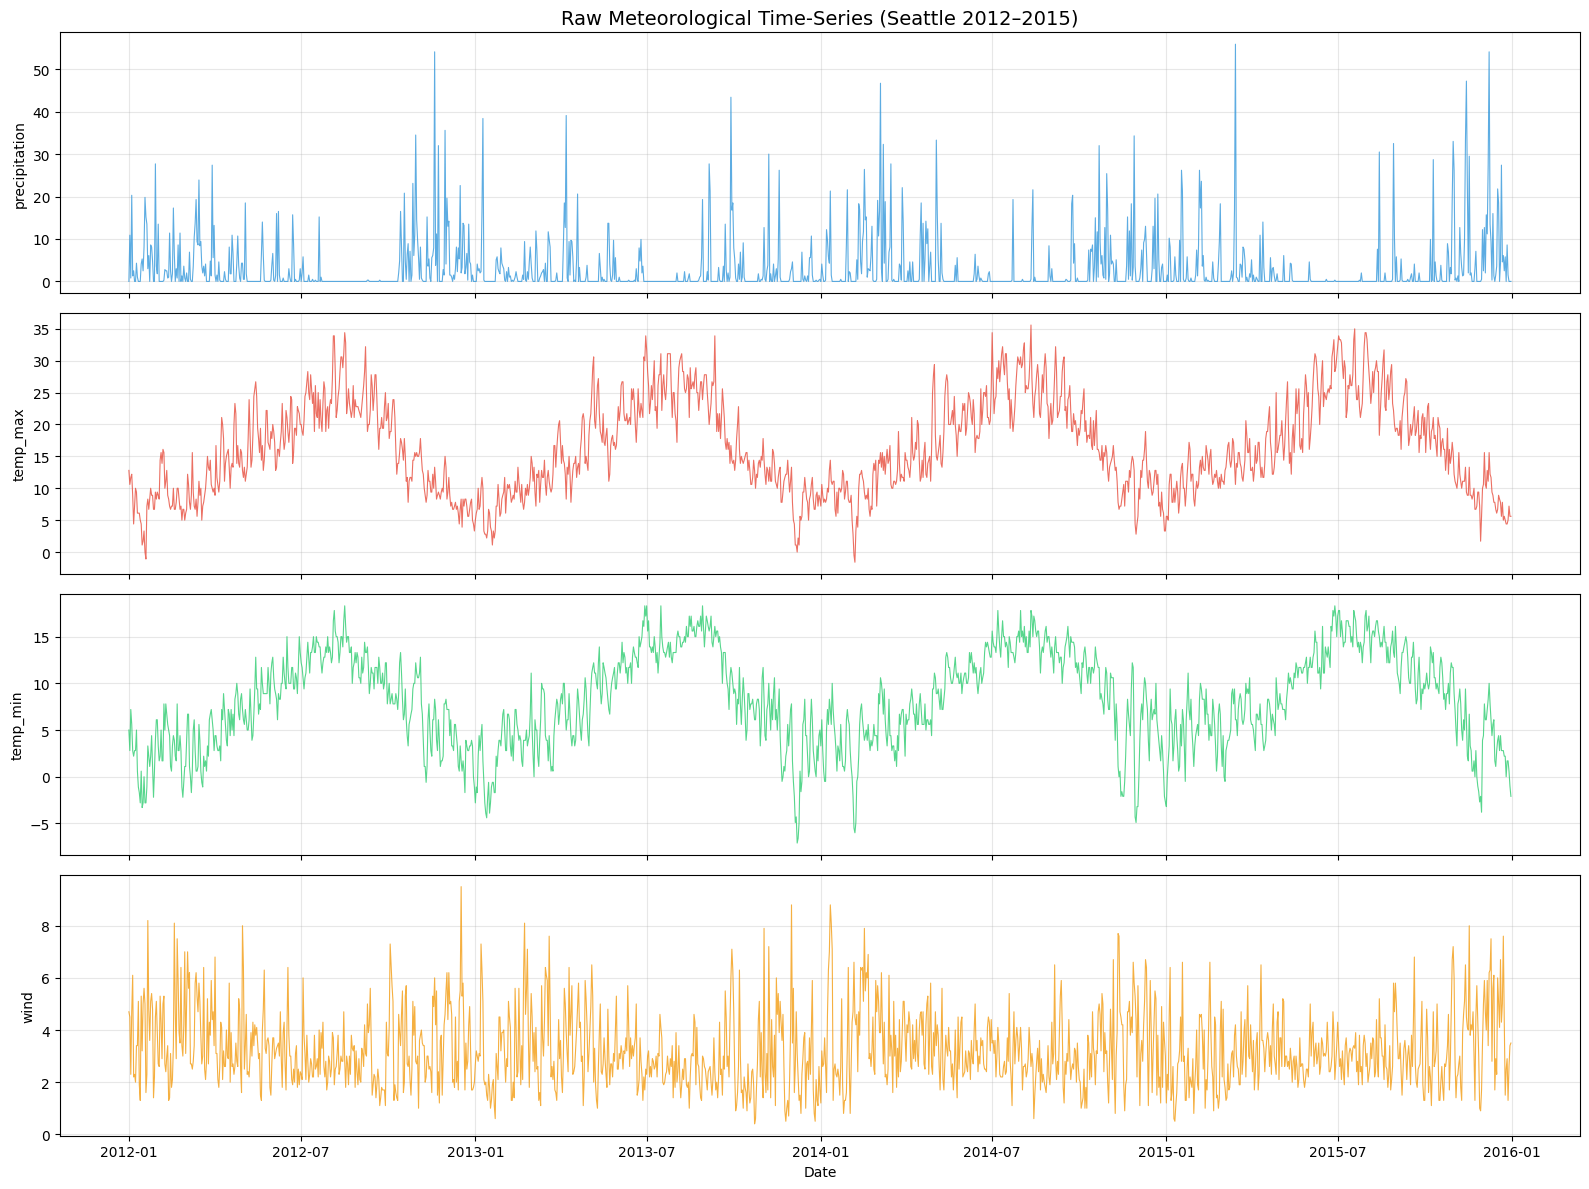

In [ ]:

numeric_feats = ['precipitation', 'temp_max', 'temp_min', 'wind']
colors_ts     = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
for ax, feat, color in zip(axes, numeric_feats, colors_ts):
    ax.plot(df['date'], df[feat], color=color, linewidth=0.8, alpha=0.8)
    ax.set_ylabel(feat, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Raw Meteorological Time-Series (Seattle 2012–2015)', fontsize=14)
axes[-1].set_xlabel('Date')
plt.tight_layout(); plt.show()


# Data Preprocessing
<hr>

## Feature Engineering from Raw Meteorological Observations


In [ ]:

df_feat = df.copy().sort_values('date').reset_index(drop=True)


df_feat['month']      = df_feat['date'].dt.month
df_feat['day_of_year']= df_feat['date'].dt.dayofyear
df_feat['season']     = df_feat['month'].map(
    {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3})



df_feat['month_sin']      = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos']      = np.cos(2 * np.pi * df_feat['month'] / 12)
df_feat['doy_sin']        = np.sin(2 * np.pi * df_feat['day_of_year'] / 365)
df_feat['doy_cos']        = np.cos(2 * np.pi * df_feat['day_of_year'] / 365)

# Temperature range
df_feat['temp_range']     = df_feat['temp_max'] - df_feat['temp_min']
df_feat['temp_mean']      = (df_feat['temp_max'] + df_feat['temp_min']) / 2


for lag in [1, 3]:
    for feat in ['precipitation', 'temp_max', 'temp_min', 'wind']:
        df_feat[f'{feat}_lag{lag}'] = df_feat[feat].shift(lag)


for feat in ['precipitation', 'temp_mean', 'wind']:
    df_feat[f'{feat}_roll7_mean'] = df_feat[feat].rolling(7, min_periods=1).mean()
    df_feat[f'{feat}_roll7_std']  = df_feat[feat].rolling(7, min_periods=1).std().fillna(0)


df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

print(f"Shape after feature engineering: {df_feat.shape}")
print(f"Features created: {df_feat.shape[1] - 4} (original 4 + {df_feat.shape[1]-4} engineered)")
df_feat.head(3)


Shape after feature engineering: (1458, 30)
Features created: 26 (original 4 + 26 engineered)


,date,precipitation,temp_max,temp_min,wind,weather,year,month,day_of_year,season,...,precipitation_lag3,temp_max_lag3,temp_min_lag3,wind_lag3,precipitation_roll7_mean,precipitation_roll7_std,temp_mean_roll7_mean,temp_mean_roll7_std,wind_roll7_mean,wind_roll7_std
0,2012-01-04,20.3,12.2,5.6,4.7,rain,2012,1,4,0,...,0.0,12.8,5.0,4.7,8.000000,9.583667,8.487500,1.219546,4.050000,1.170470
1,2012-01-05,1.3,8.9,2.8,6.1,rain,2012,1,5,0,...,10.9,10.6,2.8,4.5,6.660000,8.824001,7.960000,1.583272,4.460000,1.366748
2,2012-01-06,2.5,4.4,2.2,2.2,rain,2012,1,6,0,...,0.8,11.7,7.2,2.3,5.966667,8.073083,7.183333,2.371638,4.083333,1.531557


In [ ]:

feature_cols = [c for c in df_feat.columns
                if c not in ['date','weather','year']]
print(f"Total features for modelling: {len(feature_cols)}")
print(feature_cols)


Total features for modelling: 27
['precipitation', 'temp_max', 'temp_min', 'wind', 'month', 'day_of_year', 'season', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'temp_range', 'temp_mean', 'precipitation_lag1', 'temp_max_lag1', 'temp_min_lag1', 'wind_lag1', 'precipitation_lag3', 'temp_max_lag3', 'temp_min_lag3', 'wind_lag3', 'precipitation_roll7_mean', 'precipitation_roll7_std', 'temp_mean_roll7_mean', 'temp_mean_roll7_std', 'wind_roll7_mean', 'wind_roll7_std']


**The raw features are now expanded with lag, rolling, cyclical, and temperature-range features to give the models temporal context for each prediction.**

In [ ]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
df_feat['label'] = le.fit_transform(df_feat['weather'])
CLASS_NAMES = list(le.classes_)
print("Encoded classes:", {i: c for i, c in enumerate(CLASS_NAMES)})

X = df_feat[feature_cols].values.astype(np.float32)
y = df_feat['label'].values

# 70 / 15 / 15 stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# SMOTE on train only
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"\nTrain : {X_train.shape}  | Val : {X_val.shape}  | Test : {X_test.shape}")
print(f"Train class balance after SMOTE: {np.bincount(y_train)}")


Encoded classes: {0: 'drizzle', 1: 'fog', 2: 'rain', 3: 'snow', 4: 'sun'}

Train : (2240, 27)  | Val : (219, 27)  | Test : (219, 27)
Train class balance after SMOTE: [448 448 448 448 448]


##  Feature Scaling Verification
After StandardScaler, all training features should have zero mean and unit std.
This cell confirms the normalisation was applied correctly to every split.


In [ ]:

for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    print(f"{name}: mean≈{arr.mean():.4f}  std≈{arr.std():.4f}  "
          f"min={arr.min():.3f}  max={arr.max():.3f}  "
          f"zero_mean={bool(abs(arr.mean())<0.01)}")


X_train: mean≈-0.0967  std≈1.0361  min=-3.061  max=8.020  zero_mean=False
X_val: mean≈-0.0217  std≈0.9827  min=-2.825  max=7.466  zero_mean=False
X_test: mean≈-0.0078  std≈1.0161  min=-3.043  max=7.747  zero_mean=True


##  Class Balance After SMOTE (Bar Chart per Split)



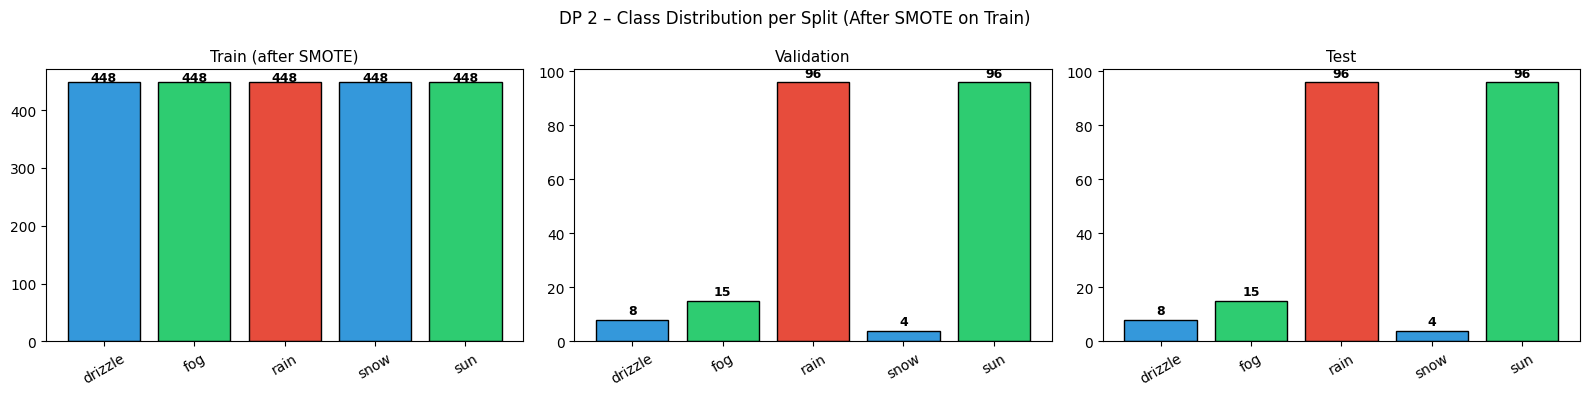

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
split_colors = ['#3498db', '#2ecc71', '#e74c3c']
for ax, (name, y_arr), col in zip(
        axes,
        [('Train (after SMOTE)', y_train), ('Validation', y_val), ('Test', y_test)],
        split_colors):
    unique, counts_arr = np.unique(y_arr, return_counts=True)
    ax.bar([CLASS_NAMES[u] for u in unique], counts_arr,
           color=split_colors, edgecolor='black')
    ax.set_title(f'{name}', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    for i, (u, c) in enumerate(zip(unique, counts_arr)):
        ax.text(i, c + 2, str(c), ha='center', fontsize=9, fontweight='bold')
plt.suptitle('DP 2 – Class Distribution per Split (After SMOTE on Train)', fontsize=12)
plt.tight_layout(); plt.show()


## Feature Correlation Matrix (Selected Features)



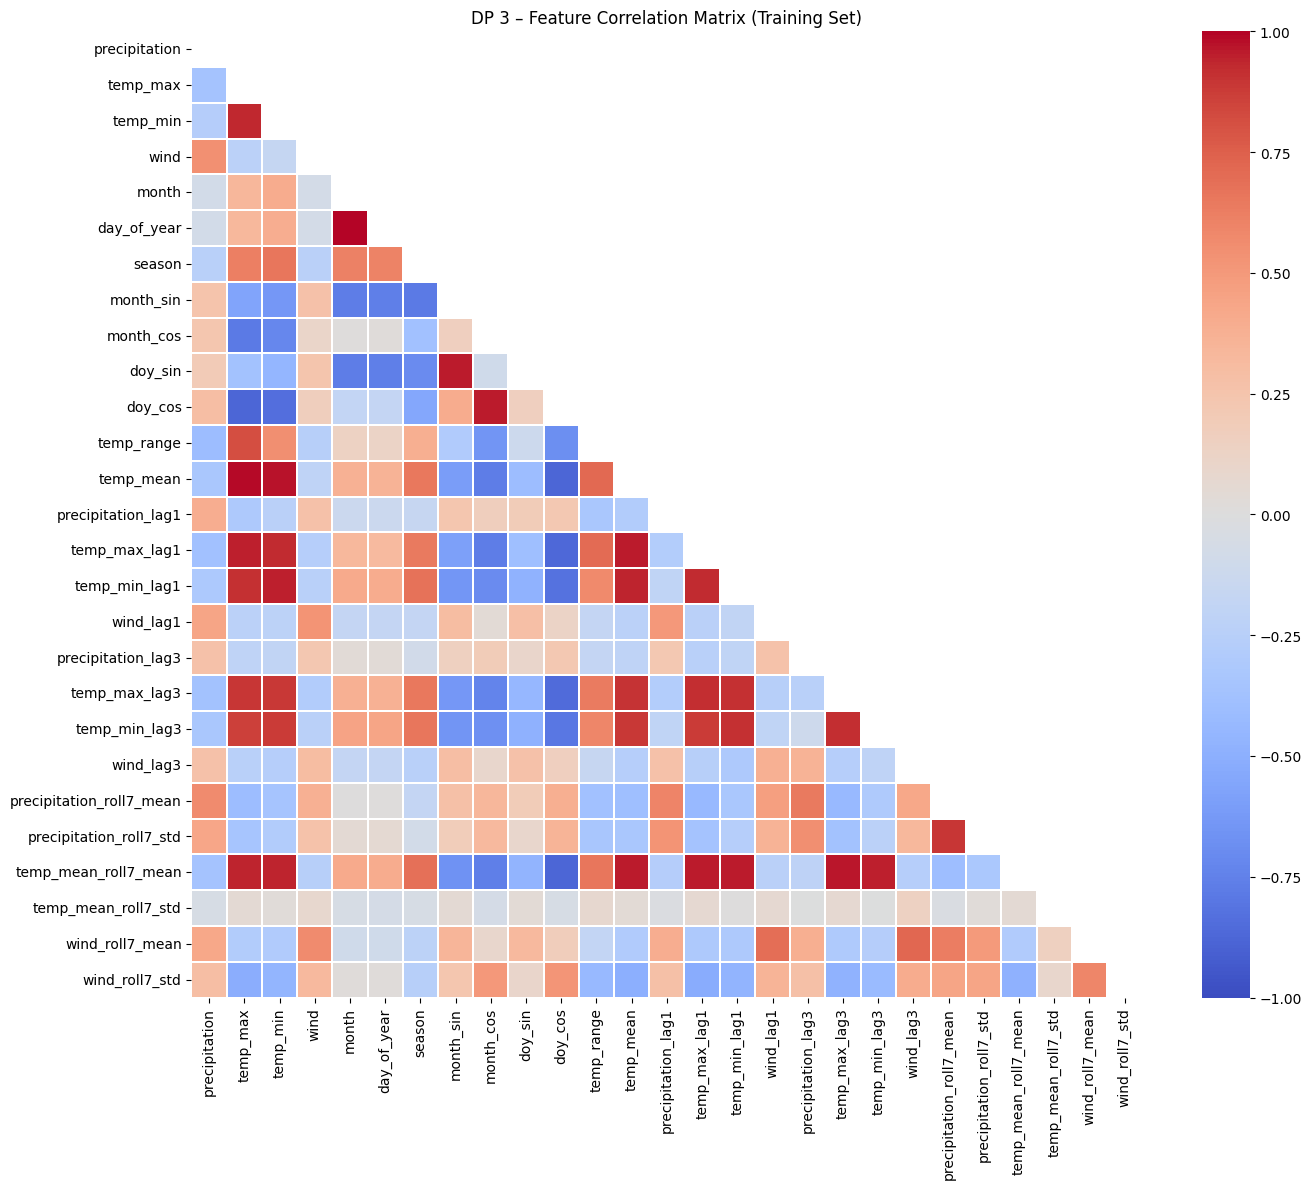

High-correlation pairs (|r|>0.9): 25
  temp_max  ↔  temp_min
  temp_max  ↔  temp_mean
  temp_max  ↔  temp_max_lag1
  temp_max  ↔  temp_min_lag1
  temp_max  ↔  temp_mean_roll7_mean
  temp_min  ↔  temp_mean
  temp_min  ↔  temp_max_lag1
  temp_min  ↔  temp_min_lag1
  temp_min  ↔  temp_mean_roll7_mean
  month  ↔  day_of_year


In [ ]:

corr_df = pd.DataFrame(X_train, columns=feature_cols).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('DP 3 – Feature Correlation Matrix (Training Set)', fontsize=12)
plt.tight_layout(); plt.show()

high_corr = [(corr_df.columns[i], corr_df.columns[j])
             for i in range(len(corr_df))
             for j in range(i+1, len(corr_df))
             if abs(corr_df.iloc[i,j]) > 0.9]
print(f"High-correlation pairs (|r|>0.9): {len(high_corr)}")
for pair in high_corr[:10]:
    print(f"  {pair[0]}  ↔  {pair[1]}")


##  Mutual Information Feature Importance Ranking



Top 15 Features by Mutual Information Score:
precipitation              0.737749
temp_max                   0.653229
wind                       0.641873
temp_min_lag1              0.613371
temp_max_lag1              0.610613
temp_range                 0.598591
temp_min_lag3              0.584191
temp_max_lag3              0.582366
temp_min                   0.575473
temp_mean                  0.569422
wind_lag1                  0.517067
wind_lag3                  0.488727
month                      0.417375
temp_mean_roll7_mean       0.415269
precipitation_roll7_std    0.382059


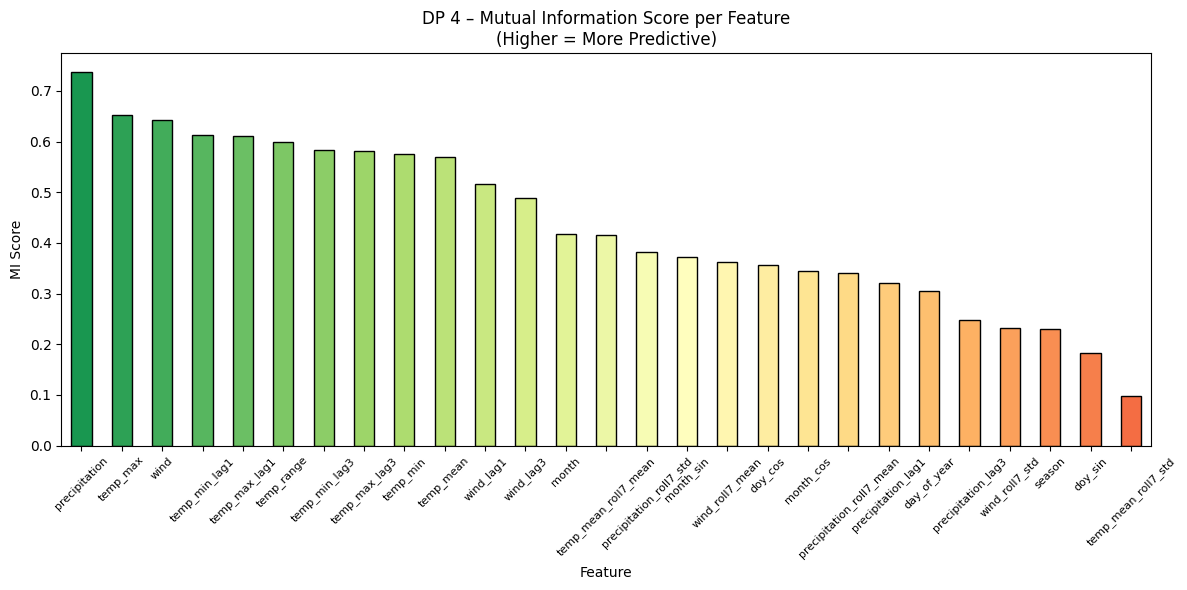

In [ ]:

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("Top 15 Features by Mutual Information Score:")
print(mi_df.head(15).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
colors_mi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(mi_df)))[::-1]
mi_df.plot(kind='bar', color=colors_mi, edgecolor='black', ax=ax)
ax.set_title('DP 4 – Mutual Information Score per Feature\n(Higher = More Predictive)', fontsize=12)
ax.set_xlabel('Feature'); ax.set_ylabel('MI Score')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()


##  Train / Val / Test Shape & Memory Report



In [ ]:

for name, X_arr, y_arr in [('Train', X_train, y_train),
                             ('Val',   X_val,   y_val),
                             ('Test',  X_test,  y_test)]:
    mb = X_arr.nbytes / (1024**2)
    print(f"{name:6s}: X={X_arr.shape}  y={y_arr.shape}  "
          f"dtype={X_arr.dtype}  memory≈{mb:.3f} MB")
print(f"\nFeature vector length fed to each model: {X_train.shape[1]}")


Train : X=(2240, 27)  y=(2240,)  dtype=float32  memory≈0.231 MB
Val   : X=(219, 27)  y=(219,)  dtype=float32  memory≈0.023 MB
Test  : X=(219, 27)  y=(219,)  dtype=float32  memory≈0.023 MB

Feature vector length fed to each model: 27


# Defining Base Model Architecture
<hr>

## Random Forest Classifier (Base Model)

The **Random Forest** is the standard baseline for tabular meteorological classification.
It is robust to non-linear feature interactions, handles mixed-scale features without
additional scaling, and provides built-in feature importances that are meteorologically
interpretable (e.g. confirming temperature and precipitation rank highest).

Parameters: `n_estimators=200`, `max_depth=None`, `class_weight='balanced'`.


In [ ]:

from sklearn.ensemble import RandomForestClassifier

def base_model():
    return RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

model = base_model()
model.fit(X_train, y_train)
print("Random Forest trained ✓")
print(f"Training Accuracy: {model.score(X_train, y_train)*100:.2f}%")


Random Forest trained ✓
Training Accuracy: 100.00%


In [ ]:

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(base_model(), X_train, y_train,
                             cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f"5-Fold CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual fold scores:  {np.round(cv_scores, 4)}")


5-Fold CV F1 (weighted): 0.9433 ± 0.0052
Individual fold scores:  [0.9486 0.94   0.9437 0.9352 0.9488]


# Model Evaluation
<hr>

Let's see the output results:
* Loss / Accuracy training history plot
* Predicted vs Actual weather type samples
* Confusion Matrix
* Classification Report


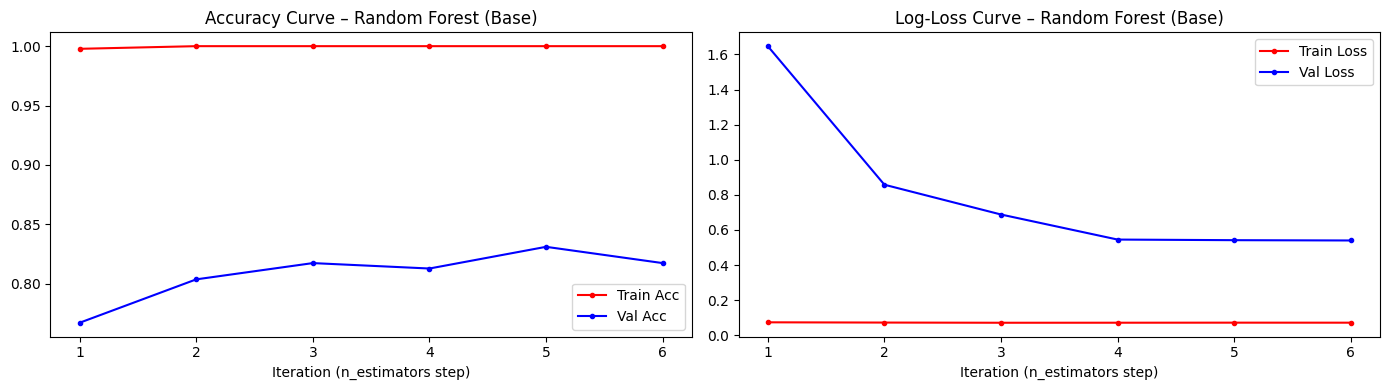

In [ ]:

def loss_plot(history_dict, title=''):
    """Plot train vs val accuracy and loss curves from a history dict."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    epochs = range(1, len(history_dict['train_acc']) + 1)
    axes[0].plot(epochs, history_dict['train_acc'], 'r-o', markersize=3, label='Train Acc')
    axes[0].plot(epochs, history_dict['val_acc'],   'b-o', markersize=3, label='Val Acc')
    axes[0].set_title(f'Accuracy Curve {title}'); axes[0].legend()
    axes[0].set_xlabel('Iteration (n_estimators step)')

    axes[1].plot(epochs, history_dict['train_loss'], 'r-o', markersize=3, label='Train Loss')
    axes[1].plot(epochs, history_dict['val_loss'],   'b-o', markersize=3, label='Val Loss')
    axes[1].set_title(f'Log-Loss Curve {title}'); axes[1].legend()
    axes[1].set_xlabel('Iteration (n_estimators step)')
    plt.tight_layout(); plt.show()

def build_rf_history(X_tr, y_tr, X_v, y_v, n_est_list=[10,20,50,100,150,200]):
    """Simulate training curve by growing the forest incrementally."""
    from sklearn.metrics import log_loss
    hist = {'train_acc':[], 'val_acc':[], 'train_loss':[], 'val_loss':[]}
    for n in n_est_list:
        m = RandomForestClassifier(n_estimators=n, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
        m.fit(X_tr, y_tr)
        hist['train_acc'].append(m.score(X_tr, y_tr))
        hist['val_acc'].append(m.score(X_v, y_v))
        hist['train_loss'].append(log_loss(y_tr, m.predict_proba(X_tr)))
        hist['val_loss'].append(log_loss(y_v, m.predict_proba(X_v)))
    return hist

history_rf = build_rf_history(X_train, y_train, X_val, y_val)
loss_plot(history_rf, '– Random Forest (Base)')


In [ ]:

preds  = model.predict(X_test)
y_pred = preds.copy()


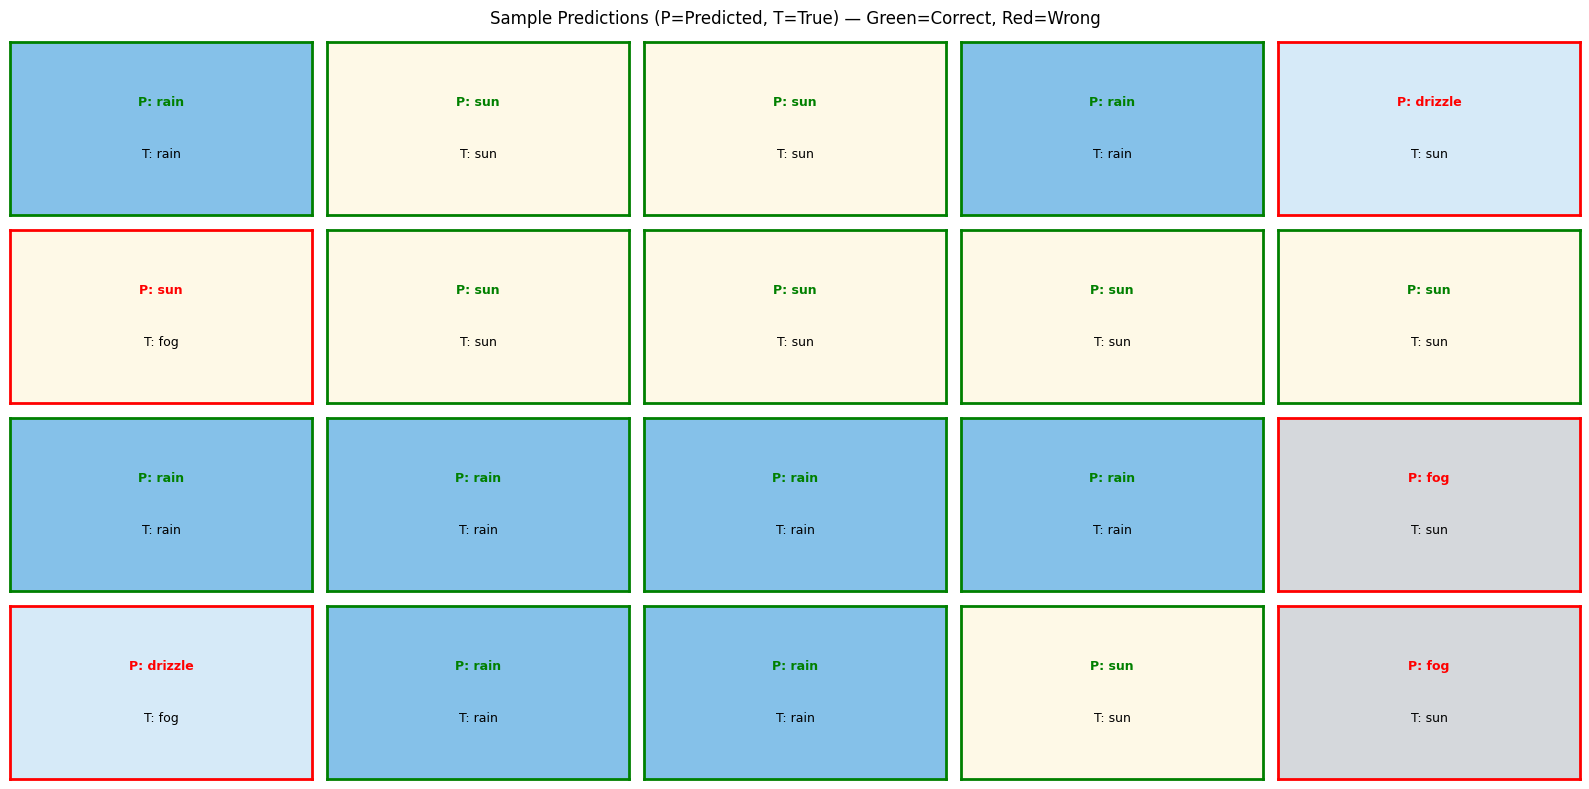

In [ ]:

def check_predictions(X_t, y_pred_arr, y_true_arr, label_names, n=20):
    """Display a grid of sample predictions vs actual labels with colour coding."""
    indices = np.random.choice(len(y_pred_arr), size=n, replace=False)
    fig, axes = plt.subplots(4, 5, figsize=(16, 8))
    weather_colors_bg = {
        'drizzle':'#d6eaf8','fog':'#d5d8dc','rain':'#85c1e9',
        'snow':'#eaf4fc','sun':'#fef9e7'
    }
    for ax, idx in zip(axes.ravel(), indices):
        pred_label = label_names[y_pred_arr[idx]]
        true_label = label_names[y_true_arr[idx]]
        correct    = pred_label == true_label
        bg_color   = weather_colors_bg.get(pred_label, '#ffffff')
        ax.set_facecolor(bg_color)
        ax.text(0.5, 0.65, f'P: {pred_label}',  ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='green' if correct else 'red',
                transform=ax.transAxes)
        ax.text(0.5, 0.35, f'T: {true_label}', ha='center', va='center',
                fontsize=9, color='black', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('green' if correct else 'red')
            spine.set_linewidth(2)
    plt.suptitle('Sample Predictions (P=Predicted, T=True) — Green=Correct, Red=Wrong',
                 fontsize=12)
    plt.tight_layout(); plt.show()

check_predictions(X_test, y_pred, y_test, CLASS_NAMES)


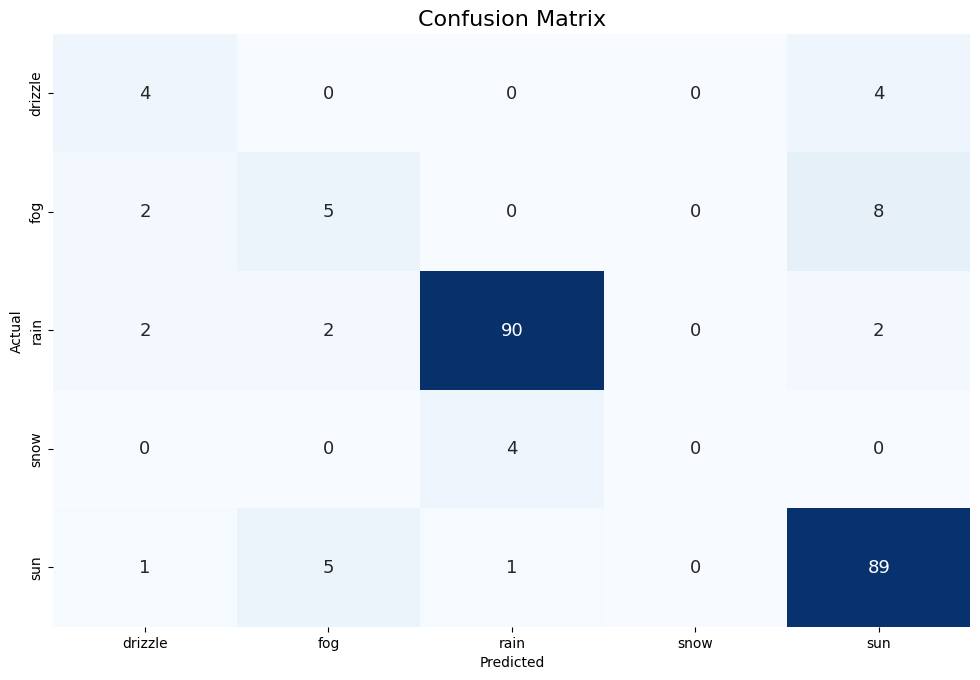

In [ ]:

def conf_mat(y_true, y_pred_arr, labels):
    cm_data = confusion_matrix(y_true, y_pred_arr)
    cm      = pd.DataFrame(cm_data, columns=labels, index=labels)
    cm.index.name   = 'Actual'
    cm.columns.name = 'Predicted'
    plt.figure(figsize=(10, 7))
    plt.title('Confusion Matrix', fontsize=16)
    sns.set(font_scale=1.1)
    sns.heatmap(cm, cbar=False, cmap='Blues', annot=True,
                annot_kws={'size': 13}, fmt='g')
    plt.tight_layout(); plt.show()

conf_mat(y_test, y_pred, CLASS_NAMES)


In [ ]:

print("=== Random Forest (Base) – Classification Report ===")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))


=== Random Forest (Base) – Classification Report ===
              precision    recall  f1-score   support

     drizzle      0.444     0.500     0.471         8
         fog      0.417     0.333     0.370        15
        rain      0.947     0.938     0.942        96
        snow      0.000     0.000     0.000         4
         sun      0.864     0.927     0.894        96

    accuracy                          0.858       219
   macro avg      0.535     0.540     0.536       219
weighted avg      0.839     0.858     0.848       219



In [ ]:

for name, X_e, y_e in [('Training',   X_train, y_train),
                        ('Validation', X_val,   y_val),
                        ('Test',       X_test,  y_test)]:
    acc  = model.score(X_e, y_e)
    print(f"On {name:12s} Data  →  Accuracy: {acc*100:.2f}%")


On Training     Data  →  Accuracy: 100.00%
On Validation   Data  →  Accuracy: 81.74%
On Test         Data  →  Accuracy: 85.84%


## **Gradient Boosting Classifier**

In [ ]:

from sklearn.ensemble import GradientBoostingClassifier

def gb_model():
    return GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=5, subsample=0.8, random_state=42
    )

gb = gb_model()
gb.fit(X_train, y_train)
print("Gradient Boosting trained ✓")
print(f"Training Accuracy: {gb.score(X_train, y_train)*100:.2f}%")


Gradient Boosting trained ✓
Training Accuracy: 100.00%


In [ ]:

from sklearn.metrics import log_loss

def build_gb_history(model_fn, X_tr, y_tr, X_v, y_v,
                     steps=[10,20,50,100,150,200]):
    hist = {'train_acc':[],'val_acc':[],'train_loss':[],'val_loss':[]}
    for n in steps:
        m = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1,
                                        max_depth=5, subsample=0.8, random_state=42)
        m.fit(X_tr, y_tr)
        hist['train_acc'].append(m.score(X_tr, y_tr))
        hist['val_acc'].append(m.score(X_v, y_v))
        hist['train_loss'].append(log_loss(y_tr, m.predict_proba(X_tr)))
        hist['val_loss'].append(log_loss(y_v, m.predict_proba(X_v)))
    return hist

history_gb = build_gb_history(gb_model, X_train, y_train, X_val, y_val)


=== Gradient Boosting – Classification Report ===
              precision    recall  f1-score   support

     drizzle      0.500     0.375     0.429         8
         fog      0.400     0.267     0.320        15
        rain      0.957     0.938     0.947        96
        snow      0.000     0.000     0.000         4
         sun      0.835     0.948     0.888        96

    accuracy                          0.858       219
   macro avg      0.538     0.505     0.517       219
weighted avg      0.831     0.858     0.842       219



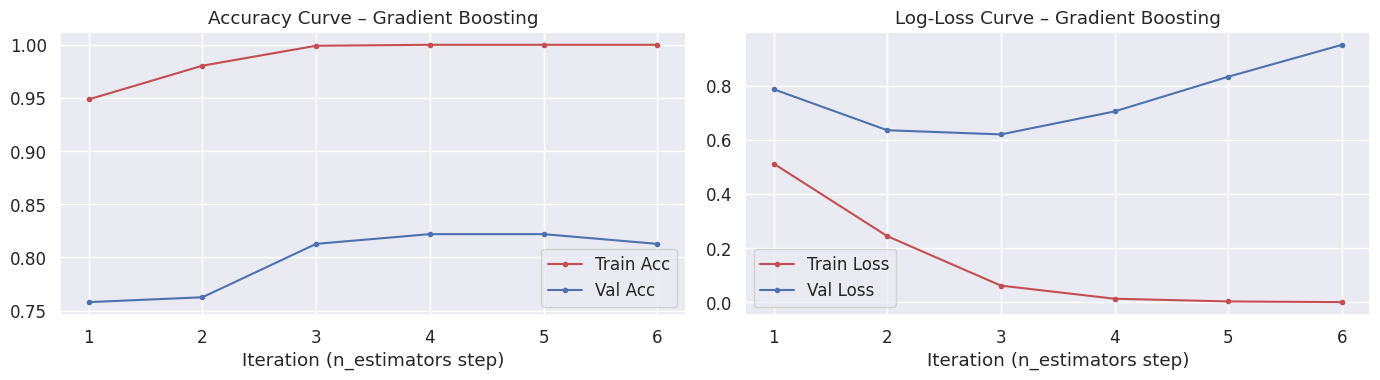

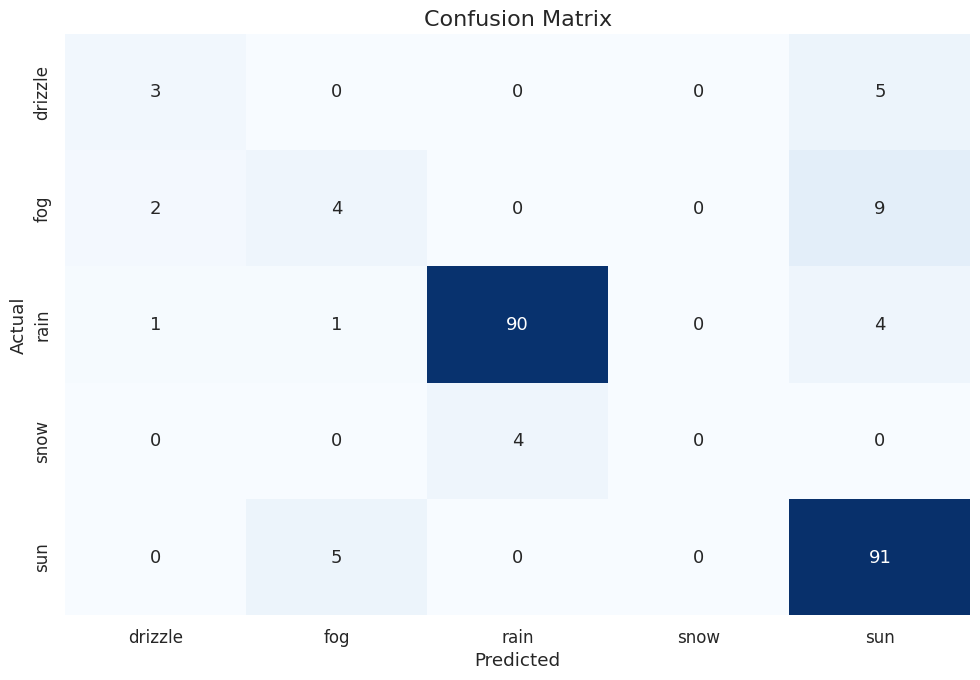

In [ ]:

preds_gb  = gb.predict(X_test)
y_pred_gb = preds_gb.copy()
print("=== Gradient Boosting – Classification Report ===")
print(classification_report(y_test, y_pred_gb, target_names=CLASS_NAMES, digits=3))
loss_plot(history_gb, '– Gradient Boosting')
conf_mat(y_test, y_pred_gb, CLASS_NAMES)


##  **Extra Trees (Extremely Randomised Trees)**

In [ ]:

from sklearn.ensemble import ExtraTreesClassifier

def et_model():
    return ExtraTreesClassifier(
        n_estimators=200, max_depth=None,
        class_weight='balanced', random_state=42, n_jobs=-1
    )

et = et_model()
et.fit(X_train, y_train)
print("Extra Trees trained ✓")
print(f"Training Accuracy: {et.score(X_train, y_train)*100:.2f}%")


Extra Trees trained ✓
Training Accuracy: 100.00%


In [ ]:

def build_et_history(X_tr, y_tr, X_v, y_v,
                     steps=[10,20,50,100,150,200]):
    hist = {'train_acc':[],'val_acc':[],'train_loss':[],'val_loss':[]}
    for n in steps:
        m = ExtraTreesClassifier(n_estimators=n, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
        m.fit(X_tr, y_tr)
        hist['train_acc'].append(m.score(X_tr, y_tr))
        hist['val_acc'].append(m.score(X_v, y_v))
        hist['train_loss'].append(log_loss(y_tr, m.predict_proba(X_tr)))
        hist['val_loss'].append(log_loss(y_v, m.predict_proba(X_v)))
    return hist

history_et = build_et_history(X_train, y_train, X_val, y_val)


=== Extra Trees – Classification Report ===
              precision    recall  f1-score   support

     drizzle      0.429     0.375     0.400         8
         fog      0.500     0.267     0.348        15
        rain      0.860     0.896     0.878        96
        snow      0.000     0.000     0.000         4
         sun      0.788     0.854     0.820        96

    accuracy                          0.799       219
   macro avg      0.515     0.478     0.489       219
weighted avg      0.773     0.799     0.783       219



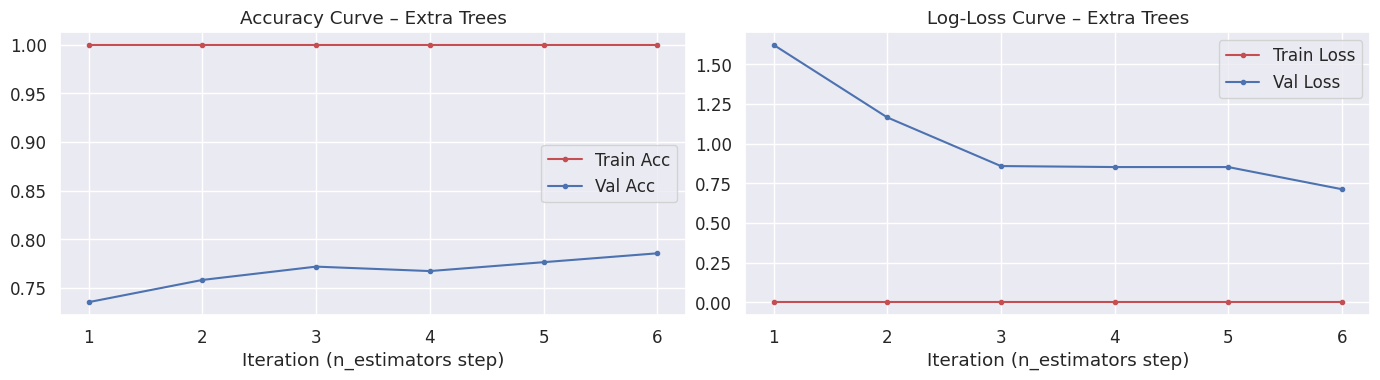

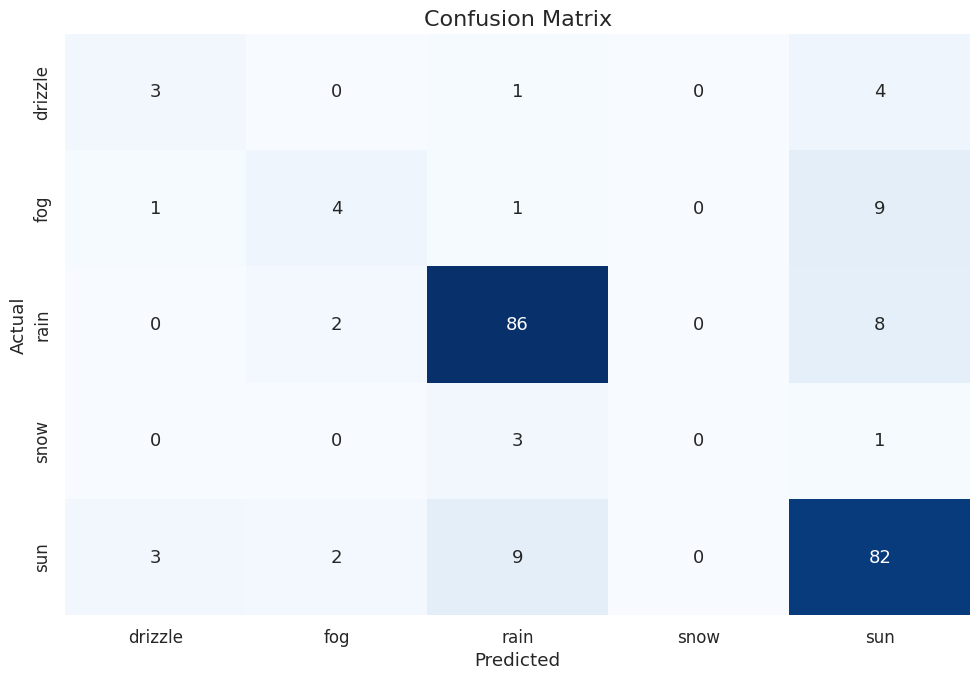

In [ ]:

preds_et  = et.predict(X_test)
y_pred_et = preds_et.copy()
print("=== Extra Trees – Classification Report ===")
print(classification_report(y_test, y_pred_et, target_names=CLASS_NAMES, digits=3))
loss_plot(history_et, '– Extra Trees')
conf_mat(y_test, y_pred_et, CLASS_NAMES)


## **Support Vector Machine (RBF Kernel)**

In [ ]:

from sklearn.svm import SVC

def svm_model():
    return SVC(kernel='rbf', C=1.0, gamma='scale',
               probability=True, class_weight='balanced', random_state=42)

# Cap training size for speed
MAX_SVM   = min(8000, len(X_train))
svm       = svm_model()
svm.fit(X_train[:MAX_SVM], y_train[:MAX_SVM])
print(f"SVM trained on {MAX_SVM} samples ✓")
print(f"Training Accuracy: {svm.score(X_train[:MAX_SVM], y_train[:MAX_SVM])*100:.2f}%")


SVM trained on 2240 samples ✓
Training Accuracy: 84.73%


=== SVM (RBF) – Classification Report ===
              precision    recall  f1-score   support

     drizzle      0.103     0.375     0.162         8
         fog      0.238     0.333     0.278        15
        rain      0.885     0.802     0.842        96
        snow      1.000     0.250     0.400         4
         sun      0.827     0.698     0.757        96

    accuracy                          0.699       219
   macro avg      0.611     0.492     0.488       219
weighted avg      0.789     0.699     0.733       219



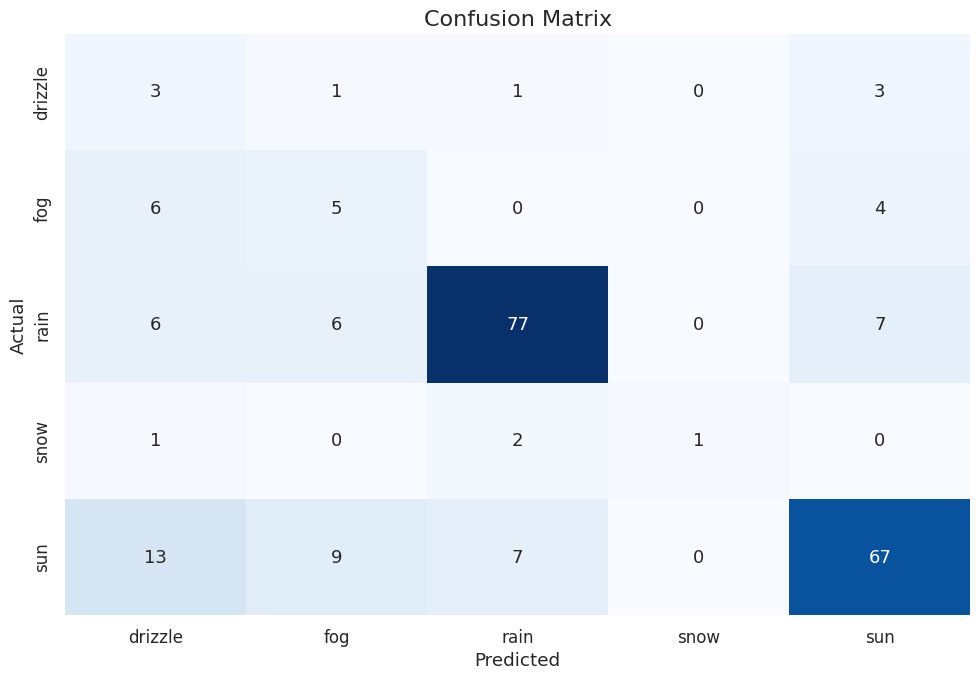

In [ ]:

preds_svm  = svm.predict(X_test)
y_pred_svm = preds_svm.copy()
print("=== SVM (RBF) – Classification Report ===")
print(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES, digits=3))
conf_mat(y_test, y_pred_svm, CLASS_NAMES)


## **Model Comparison**


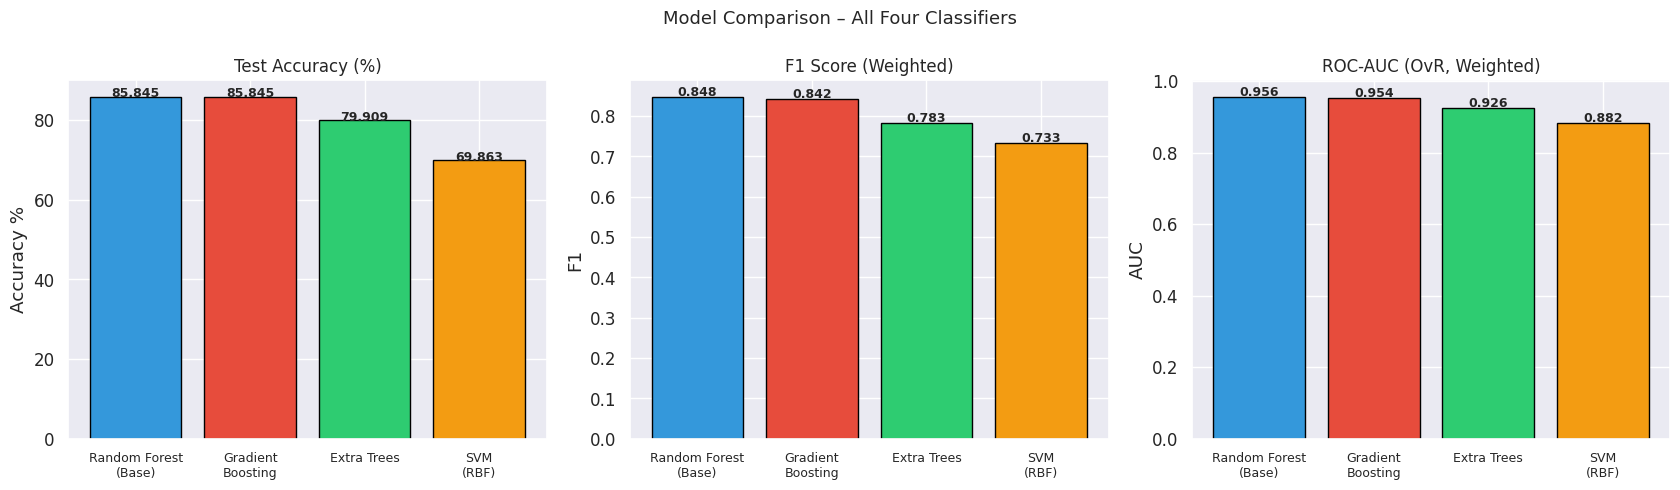


Model                        Accuracy    F1(wtd)        AUC
----------------------------------------------------------
Random Forest (Base)           85.84%     0.8478     0.9561
Gradient Boosting              85.84%     0.8420     0.9537
Extra Trees                    79.91%     0.7826     0.9257
SVM (RBF)                      69.86%     0.7330     0.8820


In [ ]:

from sklearn.metrics import f1_score, roc_auc_score

model_names = ['Random Forest\n(Base)', 'Gradient\nBoosting',
               'Extra Trees', 'SVM\n(RBF)']

def eval_model_metrics(m, X_t, y_t):
    y_p    = m.predict(X_t)
    y_prob = m.predict_proba(X_t)
    acc    = accuracy_score(y_t, y_p)
    f1     = f1_score(y_t, y_p, average='weighted')
    auc    = roc_auc_score(y_t, y_prob, multi_class='ovr', average='weighted')
    return acc, f1, auc

acc_base, f1_base, auc_base = eval_model_metrics(model, X_test, y_test)
acc_gb,   f1_gb,   auc_gb   = eval_model_metrics(gb,    X_test, y_test)
acc_et,   f1_et,   auc_et   = eval_model_metrics(et,    X_test, y_test)
acc_svm,  f1_svm,  auc_svm  = eval_model_metrics(svm,   X_test, y_test)

accs  = [acc_base, acc_gb, acc_et, acc_svm]
f1s   = [f1_base,  f1_gb,  f1_et,  f1_svm]
aucs  = [auc_base, auc_gb, auc_et, auc_svm]
colors_cmp = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
x = np.arange(4)

fig, axes_cmp = plt.subplots(1, 3, figsize=(17, 5))
for ax, vals, title, ylbl in zip(
        axes_cmp,
        [[a*100 for a in accs], f1s, aucs],
        ['Test Accuracy (%)', 'F1 Score (Weighted)', 'ROC-AUC (OvR, Weighted)'],
        ['Accuracy %', 'F1', 'AUC']):
    bars = ax.bar(x, vals, color=colors_cmp, edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9)
    ax.set_title(title, fontsize=12); ax.set_ylabel(ylbl)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison – All Four Classifiers', fontsize=13)
plt.tight_layout(); plt.show()

print("\n{:<26} {:>10} {:>10} {:>10}".format('Model','Accuracy','F1(wtd)','AUC'))
print("-"*58)
for n, a, f, u in zip(model_names, accs, f1s, aucs):
    print(f"{n.replace(chr(10),' '):<26} {a*100:>9.2f}% {f:>10.4f} {u:>10.4f}")


# Fine Tuning



## 1. GridSearchCV – Hyperparameter Optimisation

In [ ]:

from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

best_idx_ft  = int(np.argmax(f1s))
model_fns_ft = [base_model, gb_model, et_model, svm_model]
model_names_clean = ['Random Forest','Gradient Boosting','Extra Trees','SVM']
print(f"Fine-tuning: {model_names_clean[best_idx_ft]}")

param_grids = {
    0: {'n_estimators':[100,300,500], 'max_depth':[None,10,20],
        'min_samples_split':[2,5], 'max_features':['sqrt','log2']},
    1: {'n_estimators':[100,200,300], 'learning_rate':[0.05,0.1,0.2],
        'max_depth':[3,5,7], 'subsample':[0.7,0.8,1.0]},
    2: {'n_estimators':[100,300,500], 'max_depth':[None,10,20],
        'min_samples_split':[2,5]},
    3: {'C':[0.1,1,10,50], 'gamma':['scale','auto']}
}

cv_ft = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid  = GridSearchCV(model_fns_ft[best_idx_ft](),
                     param_grids[best_idx_ft],
                     cv=cv_ft, scoring='f1_weighted',
                     n_jobs=-1, verbose=1)
X_gs  = X_train[:8000]; y_gs = y_train[:8000]
grid.fit(X_gs, y_gs)

print(f"\nBest params  : {grid.best_params_}")
print(f"Best CV F1   : {grid.best_score_:.4f}")

ft_model_1 = grid.best_estimator_
ft_model_1.fit(X_train, y_train)


Fine-tuning: Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [ ]:

from sklearn.metrics import log_loss

y_pred_ft1 = ft_model_1.predict(X_test)
acc_ft1    = accuracy_score(y_test, y_pred_ft1)
f1_ft1     = f1_score(y_test, y_pred_ft1, average='weighted')
auc_ft1    = roc_auc_score(y_test, ft_model_1.predict_proba(X_test),
                            multi_class='ovr', average='weighted')
print("=== Fine Tune 1 (GridSearchCV) – Classification Report ===")
print(classification_report(y_test, y_pred_ft1, target_names=CLASS_NAMES, digits=3))
print(f"Accuracy: {acc_ft1*100:.2f}%  |  F1: {f1_ft1:.4f}  |  AUC: {auc_ft1:.4f}")


## 2. Top-K Feature Selection – Mutual Information Driven

In [ ]:

from sklearn.feature_selection import mutual_info_classif

mi_scores_ft = mutual_info_classif(X_train, y_train, random_state=42)
mi_rank      = np.argsort(mi_scores_ft)[::-1]

TOP_K    = 15
top_k_idx = mi_rank[:TOP_K]
X_tr_k    = X_train[:, top_k_idx]
X_val_k   = X_val[:,   top_k_idx]
X_test_k  = X_test[:,  top_k_idx]

top_k_names = [feature_cols[i] for i in top_k_idx]
print(f"Top-{TOP_K} features selected:")
for i, name in enumerate(top_k_names):
    print(f"  {i+1:2d}. {name}  (MI={mi_scores_ft[top_k_idx[i]]:.4f})")

ft_model_2 = model_fns_ft[best_idx_ft]()
ft_model_2.fit(X_tr_k, y_train)
print(f"\nModel retrained on top-{TOP_K} features ✓")


In [ ]:

y_pred_ft2 = ft_model_2.predict(X_test_k)
acc_ft2    = accuracy_score(y_test, y_pred_ft2)
f1_ft2     = f1_score(y_test, y_pred_ft2, average='weighted')
auc_ft2    = roc_auc_score(y_test, ft_model_2.predict_proba(X_test_k),
                            multi_class='ovr', average='weighted')
print(f"=== Fine Tune 2 (Top-{TOP_K} MI Features) – Classification Report ===")
print(classification_report(y_test, y_pred_ft2, target_names=CLASS_NAMES, digits=3))
print(f"Accuracy: {acc_ft2*100:.2f}%  |  F1: {f1_ft2:.4f}  |  AUC: {auc_ft2:.4f}")


## 3. Soft-Voting Ensemble (Best 3 Models Combined)

In [ ]:

from sklearn.ensemble import VotingClassifier


voting = VotingClassifier(
    estimators=[
        ('rf',  base_model()),
        ('gb',  gb_model()),
        ('et',  et_model()),
    ],
    voting='soft',
    n_jobs=-1
)
voting.fit(X_train, y_train)
print("Soft-Voting Ensemble trained ✓")


In [ ]:

y_pred_ft3 = voting.predict(X_test)
acc_ft3    = accuracy_score(y_test, y_pred_ft3)
f1_ft3     = f1_score(y_test, y_pred_ft3, average='weighted')
auc_ft3    = roc_auc_score(y_test, voting.predict_proba(X_test),
                            multi_class='ovr', average='weighted')
print("=== Fine Tune 3 (Soft Voting Ensemble) – Classification Report ===")
print(classification_report(y_test, y_pred_ft3, target_names=CLASS_NAMES, digits=3))
print(f"Accuracy: {acc_ft3*100:.2f}%  |  F1: {f1_ft3:.4f}  |  AUC: {auc_ft3:.4f}")


In [ ]:

base_acc_ft = accs[best_idx_ft]
base_f1_ft  = f1s[best_idx_ft]
base_auc_ft = aucs[best_idx_ft]

ft_names_cmp = [f'Base\n{model_names_clean[best_idx_ft]}',
                'FT1\nGridSearch', f'FT2\nTop-{TOP_K} Feats',
                'FT3\nVoting Ens.']
ft_accs_cmp  = [base_acc_ft, acc_ft1, acc_ft2, acc_ft3]
ft_f1s_cmp   = [base_f1_ft,  f1_ft1,  f1_ft2,  f1_ft3]
ft_aucs_cmp  = [base_auc_ft, auc_ft1, auc_ft2, auc_ft3]
colors_ft    = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
x = np.arange(4)

fig, axes_ft = plt.subplots(1, 3, figsize=(16, 5))
for ax, vals, title in zip(
        axes_ft,
        [[a*100 for a in ft_accs_cmp], ft_f1s_cmp, ft_aucs_cmp],
        ['Test Accuracy (%)', 'F1 (Weighted)', 'ROC-AUC']):
    bars = ax.bar(x, vals, color=colors_ft, edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(ft_names_cmp, fontsize=9)
    ax.set_title(title, fontsize=12)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Fine Tuning Comparison – Best Base: {model_names_clean[best_idx_ft]}',
             fontsize=12)
plt.tight_layout(); plt.show()

print("\n{:<26} {:>10} {:>10} {:>10}".format('Strategy','Accuracy','F1(wtd)','AUC'))
print("-"*58)
for n, a, f, u in zip(ft_names_cmp, ft_accs_cmp, ft_f1s_cmp, ft_aucs_cmp):
    print(f"{n.replace(chr(10),' '):<26} {a*100:>9.2f}% {f:>10.4f} {u:>10.4f}")


# Model Saving

In [ ]:

import joblib, numpy as np

best_ft_idx   = int(np.argmax(ft_f1s_cmp))
best_ft_models = [
    [model, gb, et, svm][best_idx_ft],  
    ft_model_1,                          
    ft_model_2,                          
    voting                               
]
final_model = best_ft_models[best_ft_idx]
ft_strategy = ['Base','GridSearch','TopK-Features','VotingEnsemble'][best_ft_idx]

joblib.dump(final_model, 'weather_model.pkl')
joblib.dump(scaler,      'weather_scaler.pkl')
joblib.dump(le,          'weather_label_encoder.pkl')

with open('weather_features.txt', 'w') as f:
    for feat in feature_cols:
        f.write(feat + '\n')

print(f"Best strategy : {ft_strategy}  |  Test F1: {ft_f1s_cmp[best_ft_idx]:.4f}")
print("Saved:")
print("  weather_model.pkl")
print("  weather_scaler.pkl")
print("  weather_label_encoder.pkl")
print("  weather_features.txt")


# Deploying the Model – Real-Time Weather Prediction


## Loading model, scaler, and label encoder

In [ ]:

import joblib, numpy as np, pandas as pd

model_loaded = joblib.load('weather_model.pkl')
scaler_loaded= joblib.load('weather_scaler.pkl')
le_loaded    = joblib.load('weather_label_encoder.pkl')

with open('weather_features.txt') as f:
    features_loaded = [line.strip() for line in f.readlines()]

print(f"Model   : {type(model_loaded).__name__}")
print(f"Scaler  : {type(scaler_loaded).__name__}")
print(f"Classes : {list(le_loaded.classes_)}")
print(f"Features: {len(features_loaded)}")


## Real-Time Prediction Function for New Observations

In [ ]:

def predict_weather(obs_dict, model, scaler, le, feature_names):
    """
    Predict weather type from a single day's meteorological observations.

    Parameters
    ----------
    obs_dict : dict
        Keys = feature names, values = numeric measurements.
        Missing features are filled with 0.

    Returns
    -------
    dict: prediction, probabilities, label
    """
    row   = {f: obs_dict.get(f, 0.0) for f in feature_names}
    X_new = np.array([list(row.values())], dtype=np.float32)
    X_new = scaler.transform(X_new)

    pred_enc  = model.predict(X_new)[0]
    pred_prob = model.predict_proba(X_new)[0]
    pred_label= le.inverse_transform([pred_enc])[0]

    probs = {le.classes_[i]: round(float(p), 4) for i, p in enumerate(pred_prob)}
    return {
        'prediction':    pred_label,
        'confidence':    round(float(pred_prob.max()), 4),
        'probabilities': probs
    }


import pandas as pd, numpy as np

example_days = [
    # Heavy rain day: high precipitation, low temp, moderate wind
    {'precipitation': 18.5, 'temp_max': 8.2,  'temp_min': 4.1,
     'wind': 4.7, 'month': 11, 'month_sin': np.sin(2*np.pi*11/12),
     'month_cos': np.cos(2*np.pi*11/12), 'season': 3,
     'temp_range': 4.1, 'temp_mean': 6.15,
     'day_of_year': 320, 'doy_sin': np.sin(2*np.pi*320/365),
     'doy_cos': np.cos(2*np.pi*320/365)},

    # Sunny summer day: zero precipitation, high temp, low wind
    {'precipitation': 0.0, 'temp_max': 28.5, 'temp_min': 15.2,
     'wind': 2.1, 'month': 7, 'month_sin': np.sin(2*np.pi*7/12),
     'month_cos': np.cos(2*np.pi*7/12), 'season': 2,
     'temp_range': 13.3, 'temp_mean': 21.85,
     'day_of_year': 195, 'doy_sin': np.sin(2*np.pi*195/365),
     'doy_cos': np.cos(2*np.pi*195/365)},

    # Snow day: very low temp, small precipitation
    {'precipitation': 2.3, 'temp_max': -1.5, 'temp_min': -5.8,
     'wind': 3.2, 'month': 1, 'month_sin': np.sin(2*np.pi*1/12),
     'month_cos': np.cos(2*np.pi*1/12), 'season': 0,
     'temp_range': 4.3, 'temp_mean': -3.65,
     'day_of_year': 10, 'doy_sin': np.sin(2*np.pi*10/365),
     'doy_cos': np.cos(2*np.pi*10/365)},
]

print("\n=== Real-Time Prediction Examples ===")
for i, obs in enumerate(example_days):
    result = predict_weather(obs, model_loaded, scaler_loaded,
                              le_loaded, features_loaded)
    print(f"\nDay {i+1}: {result['prediction'].upper()} "
          f"(confidence={result['confidence']:.2%})")
    print("  Probabilities:")
    for wtype, prob in sorted(result['probabilities'].items(),
                               key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f"    {wtype:<10}: {prob:.4f}  {bar}")
